<a href="https://colab.research.google.com/github/wilson121231/QRT-project-for-public/blob/main/GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import networkx as nx

In [ ]:
# 加载数据
train_input = pd.read_csv("./data/X_train.csv")
train_output = pd.read_csv("./data/Y_train.csv")
test_input = pd.read_csv("./data/X_test.csv")
supp_df =  pd.read_csv("./data/supplementary_data.csv", skip_blank_lines=True)

In [ ]:
print("🔧 特征处理...")
ret_cols = [col for col in train_input.columns if col.startswith("RET_")]
train_input[ret_cols] = train_input[ret_cols].fillna(0)
test_input[ret_cols] = test_input[ret_cols].fillna(0)

train_df = train_input.merge(train_output, on="ID")
train_df["target"] = train_df["RET_TARGET"].apply(lambda x: 1 if x > 0 else -1)

def add_stat_features(df):
    df['ret_mean'] = df[ret_cols].mean(axis=1)
    df['ret_std'] = df[ret_cols].std(axis=1)
    df['ret_max'] = df[ret_cols].max(axis=1)
    df['ret_min'] = df[ret_cols].min(axis=1)
    df['ret_pos_ratio'] = (df[ret_cols] > 0).sum(axis=1) / len(ret_cols)
    return df

train_df = add_stat_features(train_df)
test_input = add_stat_features(test_input)

🔧 特征处理...


C:\Users\6666s\AppData\Local\Temp\ipykernel_56716\3739713194.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ret_mean'] = df[ret_cols].mean(axis=1)
C:\Users\6666s\AppData\Local\Temp\ipykernel_56716\3739713194.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['ret_std'] = df[ret_cols].std(axis=1)
C:\Users\6666s\AppData\Local\Temp\ipykernel_56716\3739713194.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

In [ ]:
X_cols = [
    col for col in train_df.columns
    if col not in ['ID', 'ID_TARGET', 'target', 'ID_asset', 'CLASS_LEVEL_1', 'CLASS_LEVEL_2', 'CLASS_LEVEL_3', 'CLASS_LEVEL_4','RET_TARGET']
    and not col.endswith('_x') and not col.endswith('_y')
]

In [ ]:
# Step 1: 构造图结构
G = nx.Graph()

# 正确构图：先建立所有资产之间的连接
for _, group in supp_df.groupby("CLASS_LEVEL_4"):
    nodes = group["ID_asset"].astype(str).tolist()
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            G.add_edge(nodes[i], nodes[j])

# 再过滤图中不在训练数据中的资产节点
valid_ids = set(train_df["ID_TARGET"].astype(str).unique())
G = G.subgraph([n for n in G.nodes if n in valid_ids]).copy()

# 节点索引映射
id_map = {node: i for i, node in enumerate(G.nodes)}
edge_index = torch.tensor(
    [[id_map[u], id_map[v]] for u, v in G.edges],
    dtype=torch.long
).t().contiguous()

# ========= Step 2: 特征与标签 =========
node_features = []
labels = []
node_mask = []

for node in G.nodes:
    asset_rows = train_df[train_df["ID_TARGET"].astype(str) == node]
    if not asset_rows.empty:
        feat = asset_rows.iloc[0][X_cols].values
        label = 1 if asset_rows.iloc[0]["target"] == 1 else 0
        node_features.append(feat)
        labels.append(label)
        node_mask.append(True)
    else:
        node_features.append([0] * len(X_cols))
        labels.append(0)
        node_mask.append(False)

x = torch.tensor(np.array(node_features), dtype=torch.float)
y = torch.tensor(np.array(labels), dtype=torch.long)
mask = torch.tensor(node_mask, dtype=torch.bool)

# step 2.5: 标准化 x
x_mean = x.mean(dim=0, keepdim=True)
x_std = x.std(dim=0, keepdim=True) + 1e-6
x = (x - x_mean) / x_std
# ========= Step 3: 构建 PyG 图数据对象 =========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = Data(x=x, edge_index=edge_index, y=y).to(device)
mask = mask.to(device)
y = y.to(device)


In [ ]:
print("图中节点数：", len(G.nodes))
print("图中边数：", len(G.edges))
print("训练样本数（mask 为 True 的个数）：", mask.sum().item())
print("特征矩阵维度 x.shape：", x.shape)
print("标签分布：", y[mask].unique(return_counts=True))

图中节点数： 88
图中边数： 142
训练样本数（mask 为 True 的个数）： 88
特征矩阵维度 x.shape： torch.Size([88, 106])
标签分布： (tensor([0, 1], device='cuda:0'), tensor([26, 62], device='cuda:0'))


In [ ]:

# ========= Step 4: GCN 模型定义 =========
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
        self.dropout = torch.nn.Dropout(0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.leaky_relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# ========= Step 5: 训练 GCN =========
gcn_model = GCN(input_dim=x.size(1), hidden_dim=32, output_dim=2).to(device)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01)

for epoch in range(100):
    gcn_model.train()
    optimizer.zero_grad()
    out = gcn_model(data)
    loss = F.nll_loss(out[mask], y[mask])
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        gcn_model.eval()
        with torch.no_grad():
            pred = out[mask].argmax(dim=1)
            acc = (pred == y[mask]).float().mean().item()
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")


Epoch 0, Loss: 0.6857, Accuracy: 0.7045
Epoch 10, Loss: 0.6141, Accuracy: 0.7045
Epoch 20, Loss: 0.6072, Accuracy: 0.7045
Epoch 30, Loss: 0.6083, Accuracy: 0.7045
Epoch 40, Loss: 0.6076, Accuracy: 0.7045
Epoch 50, Loss: 0.6071, Accuracy: 0.7045
Epoch 60, Loss: 0.6070, Accuracy: 0.7045
Epoch 70, Loss: 0.6070, Accuracy: 0.7045
Epoch 80, Loss: 0.6070, Accuracy: 0.7045
Epoch 90, Loss: 0.6069, Accuracy: 0.7045


In [ ]:
gcn_model.eval()
with torch.no_grad():
    out = gcn_model(data)
    probs = torch.exp(out)  # log_softmax → softmax
    pred_labels = probs.argmax(dim=1).cpu().numpy()

# 收集 GCN 的结果（仅对 mask==True 的节点）
gcn_results = []
for idx in torch.where(mask)[0]:
    id_target = list(G.nodes)[idx.item()]
    true_label = y[idx].item()
    pred_label = pred_labels[idx.item()]
    prob = probs[idx][pred_label].item()
    gcn_results.append({
        "ID_TARGET": id_target,
        "model": "GCN",
        "true": true_label,
        "pred": pred_label,
        "prob": prob
    })

In [ ]:
def predict_with_gcn_only(test_input, gcn_model, supp_df, X_cols, device):
    test_input = test_input.copy()
    test_input["ID_TARGET"] = test_input["ID_TARGET"].astype(str)

    # 构图：节点是资产，预测资产收益正负
    data_test, node_id_list = build_graph_data(test_input, supp_df, X_cols)
    data_test = data_test.to(device)

    # GCN 模型预测
    gcn_model.eval()
    with torch.no_grad():
        out = gcn_model(data_test)                      # shape: [num_assets, 2]
        probs = torch.exp(out)
        preds = probs.argmax(dim=1).cpu().numpy()       # 0 or 1

    # 映射预测结果：每个资产 id → 预测类别
    gcn_pred_dict = {
        asset_id: int(pred)
        for asset_id, pred in zip(node_id_list, preds)
    }

    # 为 test_input 的每一行赋预测值
    final_pred = []
    for _, row in test_input.iterrows():
        id_asset = str(row["ID_TARGET"])
        id_row = row["ID"]
        pred = gcn_pred_dict.get(id_asset, -1)
        ret_target = 1 if pred == 1 else -1
        final_pred.append({"ID": id_row, "RET_TARGET": ret_target})

    df_submit = pd.DataFrame(final_pred)
    df_submit.to_csv("submission_gcn.csv", index=False)
    print("✅ 已保存 submission_gcn.csv，总行数：", len(df_submit))
    return df_submit

In [ ]:
df_submit_gcn = predict_with_gcn_only(test_input, gcn_model, supp_df, X_cols, device)


✅ 已保存 submission_gcn.csv，总行数： 114468


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from tqdm import tqdm

models_xgb = {}
val_preds_xgb = []

# 每个目标股票单独训练 XGBoost 模型
for target in tqdm(train_df["ID_TARGET"].unique()):
    sub_df = train_df[train_df["ID_TARGET"] == target]

    if sub_df["target"].nunique() < 2 or len(sub_df) < 10:
        continue  # 样本太少或只有一个类别，跳过

    # 内部划分训练/验证集
    train_sub, val_sub = train_test_split(sub_df, test_size=0.2, random_state=42, stratify=sub_df["target"])

    X_train = train_sub[X_cols]
    y_train = (train_sub["target"] == 1).astype(int)

    X_val = val_sub[X_cols]
    y_val_true = val_sub["target"]

    # 训练 XGBoost 模型
    xgb_model = XGBClassifier(
        tree_method='gpu_hist',      # 使用 GPU 加速
        predictor='gpu_predictor',   # 使用 GPU 预测
        gpu_id=0,
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    models_xgb[str(target)]  = xgb_model

    y_val_pred = xgb_model.predict(X_val)
    y_val_pred_sign = [1 if p == 1 else -1 for p in y_val_pred]
    val_preds_xgb.extend(zip(y_val_true, y_val_pred_sign))

# 准确率评估
def calculate_accuracy(val_preds):
    correct = sum(yt == yp for yt, yp in val_preds)
    total = len(val_preds)
    return correct / total if total > 0 else 0

acc_xgb = calculate_accuracy(val_preds_xgb)
print(f"✅ XGBoost 验证集准确率: {acc_xgb:.4f}")


  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\6666s\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:22:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\6666s\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:22:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\6666s\anaconda3\Lib\site-packages\xgboost\core.py:2676: UserWarning: [16:22:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "

✅ XGBoost 验证集准确率: 0.6581


In [ ]:
def predict_test_with_gcn_xgb_threshold(test_input, gcn_model, models_xgb, supp_df, X_cols, device, threshold=0.55):
    import torch
    import pandas as pd
    import numpy as np
    from tqdm import tqdm

    test_input = test_input.copy()
    test_input["ID_TARGET"] = test_input["ID_TARGET"].astype(str)

    # Step 1: 构建图
    data_test, node_id_list = build_graph_data(test_input, supp_df, X_cols)
    data_test = data_test.to(device)

    # Step 2: GCN 模型预测（资产级别）
    gcn_model.eval()
    with torch.no_grad():
        out = gcn_model(data_test)
        probs = torch.exp(out)
        preds = probs.argmax(dim=1).cpu().numpy()
        pred_probs = probs.max(dim=1).values.cpu().numpy()

    gcn_results = {
        id_: (int(label), float(prob))
        for id_, label, prob in zip(node_id_list, preds, pred_probs)
    }

    # Step 3: XGB 模型预测（资产级别）
    xgb_results = {}
    for id_target in tqdm(test_input["ID_TARGET"].unique()):
        if id_target in gcn_results and gcn_results[id_target][1] >= threshold:
            continue  # GCN 置信度高，不需要 fallback
        if id_target not in models_xgb:
            continue
        sub_df = test_input[test_input["ID_TARGET"] == id_target]
        X = sub_df[X_cols]
        if len(X) == 0:
            continue
        model = models_xgb[id_target]
        proba = model.predict_proba(X)
        pred = proba.argmax(axis=1)[0]
        prob = proba.max(axis=1)[0]
        xgb_results[id_target] = (int(pred), float(prob))

    # Step 4: 对 test_input 每一行预测
    final_pred = []
    model_source = []

    for _, row in test_input.iterrows():
        id_ = str(row["ID_TARGET"])
        id_row = row["ID"]

        gcn_pred, gcn_prob = gcn_results.get(id_, (None, -1))
        xgb_pred, xgb_prob = xgb_results.get(id_, (None, -1))

        if gcn_pred is not None and gcn_prob >= threshold:
            pred = gcn_pred
            source = "GCN"
        elif xgb_pred is not None:
            pred = xgb_pred
            source = "XGB"
        elif gcn_pred is not None:
            pred = gcn_pred
            source = "GCN-low"
        else:
            pred = -1
            source = "Default"

        ret_target = 1 if pred == 1 else -1
        final_pred.append({"ID": id_row, "RET_TARGET": ret_target})
        model_source.append(source)

    df_submit = pd.DataFrame(final_pred)
    df_submit["model_source"] = model_source
    df_submit.to_csv("submission_XBGNN_threshold.csv", index=False)

    print("✅ 已保存 submission_XBGNN_threshold.csv，总行数：", len(df_submit))
    print(df_submit["model_source"].value_counts())

    return df_submit, gcn_results, xgb_results


In [ ]:
df_submit, gcn_results, xgb_results = predict_test_with_gcn_xgb_threshold(
    test_input=test_input,
    gcn_model=gcn_model,
    models_xgb=models_xgb,
    supp_df=supp_df,
    X_cols=X_cols,
    device=device,
    threshold = np.percentile(xgb_probs, 25)  # 你可以调大调小
)

100%|██████████| 100/100 [00:01<00:00, 68.28it/s]


✅ 已保存 submission_XBGNN_threshold.csv，总行数： 114468
model_source
XGB    79002
GCN    35466
Name: count, dtype: int64


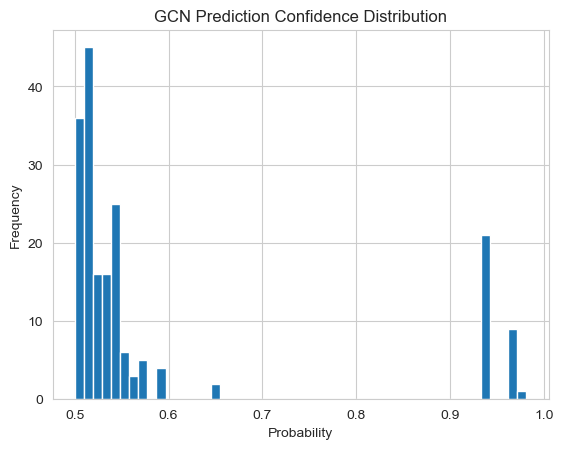

In [ ]:
import matplotlib.pyplot as plt

probs = [prob for _, prob in gcn_results.values()]
plt.hist(probs, bins=50)
plt.title("GCN Prediction Confidence Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

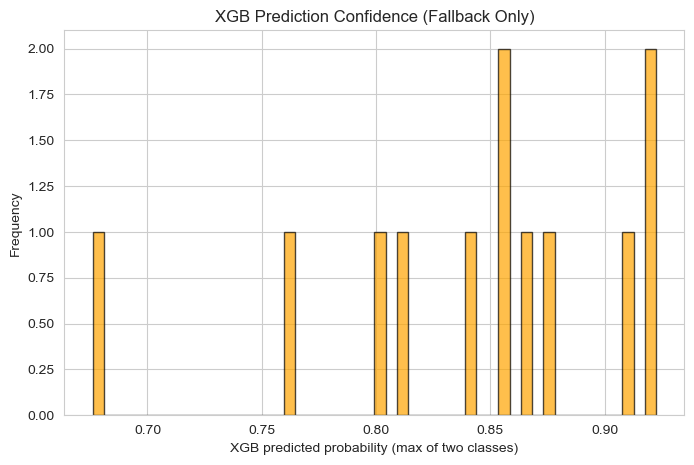

XGB 概率分布统计:
数量: 12
平均值: 0.8415
中位数: 0.8546
最大值: 0.9226
最小值: 0.6760


In [ ]:
import matplotlib.pyplot as plt

# 从 fallback 的 XGB 预测结果中提取置信度
xgb_probs = [prob for _, prob in xgb_results.values()]

# 绘制直方图
plt.figure(figsize=(8, 5))
plt.hist(xgb_probs, bins=50, alpha=0.7, color='orange', edgecolor='black')
plt.title("XGB Prediction Confidence (Fallback Only)")
plt.xlabel("XGB predicted probability (max of two classes)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 打印基本统计
import numpy as np
print("XGB 概率分布统计:")
print(f"数量: {len(xgb_probs)}")
print(f"平均值: {np.mean(xgb_probs):.4f}")
print(f"中位数: {np.median(xgb_probs):.4f}")
print(f"最大值: {np.max(xgb_probs):.4f}")
print(f"最小值: {np.min(xgb_probs):.4f}")

In [ ]:
def compare_submissions(path1, path2):
    sub1 = pd.read_csv(path1).rename(columns={"RET_TARGET": "RET_TARGET_1"})
    sub2 = pd.read_csv(path2).rename(columns={"RET_TARGET": "RET_TARGET_2"})

    # 合并两个提交文件
    merged = pd.merge(sub1, sub2, on="ID", how="inner")

    # 比较预测值是否一致
    similarity = (merged["RET_TARGET_1"] == merged["RET_TARGET_2"]).mean()
    same = (merged["RET_TARGET_1"] == merged["RET_TARGET_2"]).sum()
    total = len(merged)

    print(f"📊 submission 相似度: {similarity:.4f}（相同项数: {same} / 总共: {total}）")
    return similarity

In [ ]:
path1="./submission_gcn.csv"
path2="./submission_xgb.csv"
compare_submissions(path1, path2)

📊 submission 相似度: 0.4925（相同项数: 56381 / 总共: 114468）


0.49254813572352096

In [ ]:
df = df.drop(columns=['列名'])